# 15 Intensity ML

This copy notebook predicts event intensity, defined as the number of complaints in an observed flood event.

Only reported positive events are used in the default model. Matched negatives are not part of the count model.

Split rule:
- one classic stratified `75/15/10` train/validation/test split
- stratification uses intensity bands plus `mayoral_administration` when feasible
- model selection is a hyperparameter-grid sweep on train/validation; test is untouched final evaluation

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

,feature_group,expected_features,available_features,mean_non_null_rate,missing_features
0,event_time,8,8,0.998824,0
1,extra,18,18,0.999471,0
2,governance,3,3,1.000000,0
3,hydrometeorology,6,6,0.987104,0
4,infrastructure,4,4,0.500000,0
5,network,9,9,0.444444,0
6,socioeconomic,4,4,0.983589,0
7,spatial_controls,5,5,1.000000,0
8,targets,4,4,0.997648,0
9,terrain_coastal,8,8,0.999986,0


,feature_group,feature,available,dtype,non_null_rate,n_unique
0,event_time,day_of_week,True,Int64,1.000000,7
1,event_time,duration,True,float64,1.000000,7452
2,event_time,end,True,datetime64[us],0.990594,31625
3,event_time,hour,True,Int64,1.000000,24
4,event_time,month,True,Int64,1.000000,12
5,event_time,season,True,string,1.000000,4
6,event_time,start,True,datetime64[us],1.000000,32123
7,event_time,storm_event_id,True,string,1.000000,117
8,extra,catch_basin_nearest_ft,True,float64,1.000000,16985
9,extra,component_size,True,int64,1.000000,52


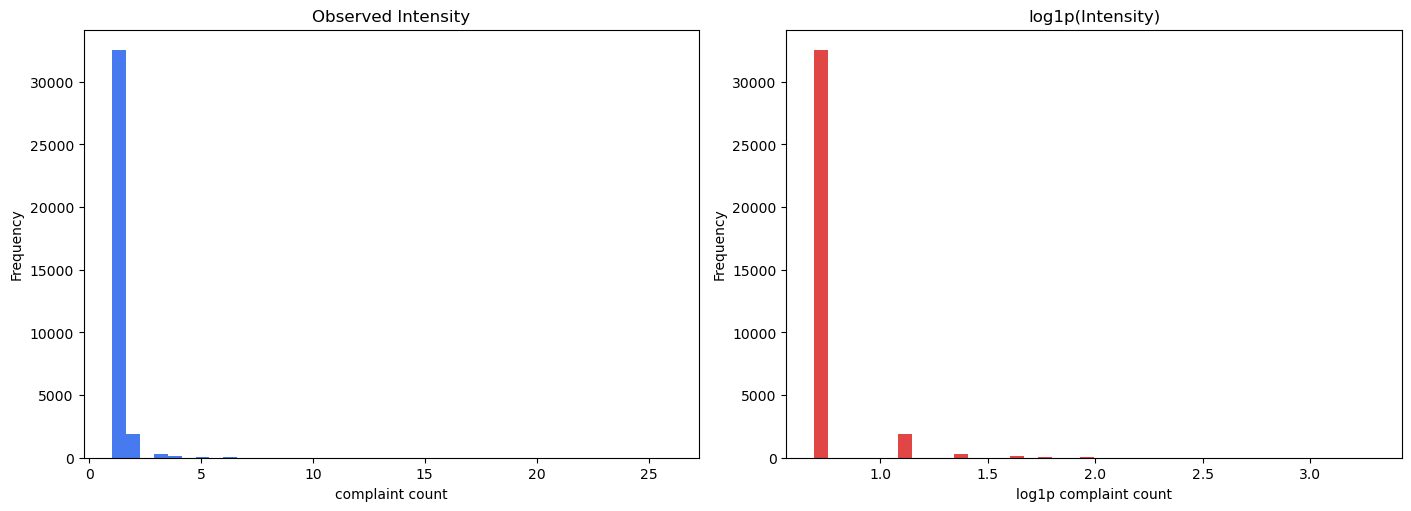

In [3]:
from project_name.modeling_stage import (
    INTENSITY_BIAS_DIAGNOSTICS_PATH,
    INTENSITY_FEATURE_IMPORTANCE_PATH,
    INTENSITY_LEAKAGE_AUDIT_PATH,
    INTENSITY_PREDICTIONS_PATH,
    INTENSITY_RESULTS_PATH,
    compact_modeling_summary,
    feature_catalog,
    load_modeling_frame,
    run_intensity_ml,
    summarize_feature_groups,
)

observed = load_modeling_frame(view_name="strict_main", include_geometry=False, observed_only=True)
display(summarize_feature_groups(observed))
display(feature_catalog(observed).head(40))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
pd.to_numeric(observed["intensity"], errors="coerce").plot.hist(ax=axes[0], bins=40, color="#2563EB", alpha=0.85)
axes[0].set_title("Observed Intensity")
axes[0].set_xlabel("complaint count")
np.log1p(pd.to_numeric(observed["intensity"], errors="coerce")).plot.hist(ax=axes[1], bins=40, color="#DC2626", alpha=0.85)
axes[1].set_title("log1p(Intensity)")
axes[1].set_xlabel("log1p complaint count")
plt.show()

In [4]:
results, predictions, feature_importance = run_intensity_ml(observed)

display(compact_modeling_summary(results, ["mae", "rmse", "r2"]).head(30))
display(results.sort_values(["mae", "rmse"], ascending=[True, True], kind="stable").head(30))
display(feature_importance.head(30))

print(f"saved: {INTENSITY_RESULTS_PATH}")
print(f"saved: {INTENSITY_PREDICTIONS_PATH}")
print(f"saved: {INTENSITY_FEATURE_IMPORTANCE_PATH}")
print(f"saved: {INTENSITY_BIAS_DIAGNOSTICS_PATH}")
print("incremental checkpoints: data/processed/modeling/diagnostics/modeling_stage/checkpoints/intensity")

/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encounte

,task_name,split_strategy,model_name,status,mae,rmse,r2,best_params,notes
0,intensity,temporal_by_administration,poisson_regressor,ok,0.173966,0.642659,-0.002258,"{""model__alpha"": 1.0}",Forward-looking temporal split by mayoral admi...
1,intensity,temporal_by_administration,tweedie_regressor,ok,0.173860,0.642608,-0.002098,"{""model__alpha"": 1.0, ""model__power"": 1.1}",Forward-looking temporal split by mayoral admi...
2,intensity,temporal_by_administration,gradient_boosting_regressor,ok,0.172741,0.641615,0.000996,"{""model__learning_rate"": 0.03, ""model__max_dep...",Forward-looking temporal split by mayoral admi...
3,intensity,temporal_by_administration,ridge,ok,0.170406,0.638690,0.010085,"{""model__alpha"": 100.0}",Forward-looking temporal split by mayoral admi...
4,intensity,temporal_by_administration,linear_regression,ok,0.170316,0.638680,0.010116,{},Forward-looking temporal split by mayoral admi...
5,intensity,temporal_by_administration,random_forest_regressor,ok,0.169953,0.639296,0.008205,"{""model__max_depth"": 20, ""model__max_features""...",Forward-looking temporal split by mayoral admi...
6,intensity,stratified_75_15_10,linear_regression,ok,0.152168,0.692509,0.022523,{},Classic 75/15/10 stratified-random split. Stra...
7,intensity,stratified_75_15_10,ridge,ok,0.152138,0.692594,0.022284,"{""model__alpha"": 100.0}",Classic 75/15/10 stratified-random split. Stra...
8,intensity,stratified_75_15_10,poisson_regressor,ok,0.151381,0.694030,0.018226,"{""model__alpha"": 0.1}",Classic 75/15/10 stratified-random split. Stra...
9,intensity,stratified_75_15_10,tweedie_regressor,ok,0.150920,0.694352,0.017314,"{""model__alpha"": 0.1, ""model__power"": 1.9}",Classic 75/15/10 stratified-random split. Stra...


,task_name,split_strategy,model_name,status,n_train,n_validation,n_test,n_features,best_params,validation_primary_score,cv_validation_primary_score,cv_train_primary_score,notes,rmse,mae,r2,median_absolute_error,spearman_correlation,pearson_correlation,mape,train_rmse,train_mae,train_r2,train_median_absolute_error,train_spearman_correlation,train_pearson_correlation,train_mape,validation_rmse,validation_mae,validation_r2,validation_median_absolute_error,validation_spearman_correlation,validation_pearson_correlation,validation_mape,test_rmse,test_mae,test_r2,test_median_absolute_error,test_spearman_correlation,test_pearson_correlation,test_mape,train_vs_validation_gap,validation_vs_test_gap,possible_overfitting,possible_test_degradation
7,intensity,stratified_75_15_10,dummy_regressor,ok,26152,5230,3488,36,{},-0.091778,-0.091778,-0.094448,Classic 75/15/10 stratified-random split. Stra...,0.707512,0.099771,-0.020289,0.000000,NaN,NaN,NaN,0.497393,0.094448,-0.037405,0.000000,NaN,NaN,NaN,0.431104,0.091778,-0.047474,0.000000,NaN,NaN,NaN,0.707512,0.099771,-0.020289,0.000000,NaN,NaN,NaN,-0.002670,0.007992,False,False
10,intensity,stratified_75_15_10,random_forest_regressor,ok,26152,5230,3488,36,"{""model__max_depth"": 10, ""model__max_features""...",-0.112693,-0.112693,-0.119487,Classic 75/15/10 stratified-random split. Stra...,0.677822,0.135435,0.063545,0.041232,0.034715,0.392032,NaN,0.430107,0.119487,0.224286,0.039943,-0.008895,0.007839,NaN,0.358186,0.112693,0.276903,0.039707,-0.051771,-0.017911,NaN,0.677822,0.135435,0.063545,0.041232,0.034715,0.392032,NaN,-0.006795,0.022742,False,False
11,intensity,stratified_75_15_10,gradient_boosting_regressor,ok,26152,5230,3488,36,"{""model__learning_rate"": 0.03, ""model__max_dep...",-0.116023,-0.116023,-0.122501,Classic 75/15/10 stratified-random split. Stra...,0.694457,0.137219,0.017017,0.038107,0.069810,0.381990,NaN,0.412340,0.122501,0.287048,0.038605,-0.007353,0.005650,NaN,0.363276,0.116023,0.256205,0.038113,-0.047806,-0.024439,NaN,0.694457,0.137219,0.017017,0.038107,0.069810,0.381990,NaN,-0.006478,0.021195,False,False
0,intensity,temporal_by_administration,dummy_regressor,ok,8570,13413,12887,36,{},-0.078133,-0.078133,-0.054142,Forward-looking temporal split by mayoral admi...,0.656725,0.138589,-0.046610,0.000000,NaN,NaN,NaN,0.362476,0.054142,-0.022820,0.000000,NaN,NaN,NaN,0.432070,0.078133,-0.033807,0.000000,NaN,NaN,NaN,0.656725,0.138589,-0.046610,0.000000,NaN,NaN,NaN,0.023991,0.060456,False,False
13,intensity,stratified_75_15_10,tweedie_regressor,ok,26152,5230,3488,36,"{""model__alpha"": 0.1, ""model__power"": 1.9}",-0.141562,-0.141562,-0.145770,Classic 75/15/10 stratified-random split. Stra...,0.694352,0.150920,0.017314,0.055070,0.044080,0.224204,NaN,0.477348,0.145770,0.044526,0.056457,-0.005168,0.008625,NaN,0.412037,0.141562,0.043136,0.056589,-0.034150,-0.066969,NaN,0.694352,0.150920,0.017314,0.055070,0.044080,0.224204,NaN,-0.004208,0.009358,False,False
12,intensity,stratified_75_15_10,poisson_regressor,ok,26152,5230,3488,36,"{""model__alpha"": 0.1}",-0.141781,-0.141781,-0.146137,Classic 75/15/10 stratified-random split. Stra...,0.694030,0.151381,0.018226,0.056065,0.045819,0.229384,NaN,0.475842,0.146137,0.050544,0.057472,-0.005149,0.008407,NaN,0.408214,0.141781,0.060809,0.057504,-0.030925,-0.065403,NaN,0.694030,0.151381,0.018226,0.056065,0.045819,0.229384,NaN,-0.004356,0.009600,False,False
9,intensity,stratified_75_15_10,ridge,ok,26152,5230,3488,36,"{""model__alpha"": 100.0}",-0.142437,-0.142437,-0.147237,Classic 75/15/10 stratified-random split. Stra...,0.692594,0.152138,0.022284,0.056877,0.057669,0.233511,NaN,0.473583,0.147237,0.059537,0.058650,-0.005756,0.007444,NaN,0.404544,0.142437,0.077617,0.058013,-0.041284,-0.070201,NaN,0.692594,0.152138,0.022284,0.056877,0.057669,0.233511,NaN,-0.004800,0.009701,False,False
8,intensity,stratified_75_15_10,linear_regression,ok,26152,5230,3488,36,{},-0.142498,-0.142498,-0.147322,Classic 75/15/10 stratified-random split. Stra...,0.692509,0.152168,0.0

,task_name,feature,importance
0,intensity,census_median_household_income,NaN
1,intensity,census_no_vehicle_share,NaN
2,intensity,census_poverty_rate,NaN
3,intensity,census_renter_share,NaN
4,intensity,component_size,NaN
5,intensity,day_of_week,NaN
6,intensity,drainage_catch_basin_nearest_ft,NaN
7,intensity,edge_betweenness,NaN
8,intensity,elevation,NaN
9,intensity,fema_overlap_ft,NaN


saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/results_intensity_ml.csv
saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/predictions_intensity_ml.parquet
saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/feature_importance_intensity.csv
saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/bias_diagnostics_intensity.csv
incremental checkpoints: data/processed/modeling/diagnostics/modeling_stage/checkpoints/intensity


In [5]:
results = pd.read_csv(INTENSITY_RESULTS_PATH)
predictions = pd.read_parquet(INTENSITY_PREDICTIONS_PATH)
feature_importance = pd.read_csv(INTENSITY_FEATURE_IMPORTANCE_PATH)
bias = pd.read_csv(INTENSITY_BIAS_DIAGNOSTICS_PATH)
leakage_audit = pd.read_csv(INTENSITY_LEAKAGE_AUDIT_PATH)

metric_cols = [
    "rmse",
    "mae",
    "r2",
    "spearman_correlation",
    "pearson_correlation",
    "median_absolute_error",
    "train_mae",
    "validation_mae",
    "test_mae",
    "cv_validation_primary_score",
    "train_vs_validation_gap",
    "validation_vs_test_gap",
    "possible_overfitting",
    "possible_test_degradation",
]
display(results[["model_name", "split_strategy", "status"] + [c for c in metric_cols if c in results.columns]].query("status == 'ok'"))
display(bias.head(50))
display(leakage_audit[leakage_audit["excluded_from_predictors"]].head(30))

,model_name,split_strategy,status,rmse,mae,r2,spearman_correlation,pearson_correlation,median_absolute_error,train_mae,validation_mae,test_mae,cv_validation_primary_score,train_vs_validation_gap,validation_vs_test_gap,possible_overfitting,possible_test_degradation
0,dummy_regressor,temporal_by_administration,ok,0.656725,0.138589,-0.046610,NaN,NaN,0.000000,0.054142,0.078133,0.138589,-0.078133,0.023991,0.060456,False,False
1,linear_regression,temporal_by_administration,ok,0.638680,0.170316,0.010116,-0.007129,-0.003514,0.044756,0.091196,0.125417,0.170316,-0.125417,0.034221,0.044898,False,False
2,ridge,temporal_by_administration,ok,0.638690,0.170406,0.010085,-0.008030,-0.004305,0.044910,0.091140,0.125368,0.170406,-0.125368,0.034228,0.045038,False,False
3,random_forest_regressor,temporal_by_administration,ok,0.639296,0.169953,0.008205,-0.021018,-0.017054,0.037228,0.081883,0.109978,0.169953,-0.109978,0.028095,0.059975,False,False
4,gradient_boosting_regressor,temporal_by_administration,ok,0.641615,0.172741,0.000996,-0.012265,-0.013004,0.036274,0.087720,0.115523,0.172741,-0.115523,0.027803,0.057219,False,False
5,poisson_regressor,temporal_by_administration,ok,0.642659,0.173966,-0.002258,-0.009216,-0.005565,0.046736,0.092038,0.124255,0.173966,-0.124255,0.032218,0.049710,False,False
6,tweedie_regressor,temporal_by_administration,ok,0.642608,0.173860,-0.002098,-0.009256,-0.005541,0.046664,0.091902,0.124201,0.173860,-0.124201,0.032299,0.049659,False,False
7,dummy_regressor,stratified_75_15_10,ok,0.707512,0.099771,-0.020289,NaN,NaN,0.000000,0.094448,0.091778,0.099771,-0.091778,-0.002670,0.007992,False,False
8,linear_regression,stratified_75_15_10,ok,0.692509,0.152168,0.022523,0.060399,0.234527,0.057017,0.147322,0.142498,0.152168,-0.142498,-0.004825,0.009671,False,False
9,ridge,stratified_75_15_10,ok,0.692594,0.152138,0.022284,0.057669,0.233511,0.056877,0.147237,0.142437,0.152138,-0.142437,-0.004800,0.009701,False,False


,task_name,set_name,bias_dimension,group_value,n,mean_residual,median_residual,mae,underprediction_rate
0,intensity,test,borough,BRONX,8610,0.083844,-0.023498,0.143889,0.144483
1,intensity,test,borough,BROOKLYN,35875,0.114041,-0.031713,0.186802,0.124767
2,intensity,test,borough,MANHATTAN,8659,0.069212,-0.020426,0.123881,0.127497
3,intensity,test,borough,QUEENS,45822,0.065688,-0.033578,0.144223,0.109271
4,intensity,test,borough,STATEN ISLAND,15659,0.084439,-0.044739,0.183205,0.077910
5,intensity,train,borough,BRONX,18011,0.023157,-0.027334,0.098662,0.133696
6,intensity,train,borough,BROOKLYN,67109,0.034284,-0.035990,0.130384,0.091463
7,intensity,train,borough,MANHATTAN,22407,0.014191,-0.022796,0.081623,0.138037
8,intensity,train,borough,QUEENS,94304,0.027456,-0.031613,0.113704,0.117185
9,intensity,train,borough,STATEN ISLAND,41223,0.042637,-0.041473,0.148306,0.084152


,feature,excluded_from_predictors,reason,dtype,non_null_rate
0,analysis_view_name,True,identifier_or_derived_selection,str,1.000000
1,catch_basin_nearest_ft,True,technical_duplicate_use_canonical_feature_name...,float64,1.000000
2,dataset_split_role,True,identifier_or_derived_selection,string,1.000000
3,dem_mean,True,technical_duplicate_use_canonical_feature_name...,float64,0.999943
4,dem_slope,True,technical_duplicate_use_canonical_feature_name...,float64,0.999943
5,duration,True,event_window_outcome_not_available_at_event_start,float64,1.000000
6,end,True,close_time_not_available_at_event_start,datetime64[us],0.990594
7,event_end_local,True,technical_duplicate_use_canonical_feature_name...,datetime64[us],0.990594
8,event_id,True,identifier_or_derived_selection,string,1.000000
9,event_month,True,technical_duplicate_use_canonical_feature_name...,Int64,1.000000


## Archetype and Anomaly Error Diagnostics

Cluster labels are used here for residual diagnostics, not as a default predictor.
This helps identify whether heavy-event, compound, or unusual event regimes are systematically underpredicted.

In [6]:
CLUSTER_PATH = ROOT / "data" / "processed" / "modeling" / "clustering_event_archetypes.parquet"
ANOMALY_PATH = ROOT / "data" / "processed" / "modeling" / "anomaly_event_scores.parquet"

if CLUSTER_PATH.exists() and ANOMALY_PATH.exists():
    clusters = pd.read_parquet(CLUSTER_PATH)[
        ["event_id", "combined_cluster_id", "cluster_label"]
    ].copy()
    anomalies = pd.read_parquet(ANOMALY_PATH)[
        ["event_id", "anomaly_score", "anomaly_flag", "anomaly_method_agreement"]
    ].copy()
    intensity_cluster_diag = (
        predictions.merge(clusters, on="event_id", how="left")
        .merge(anomalies, on="event_id", how="left")
    )
    intensity_cluster_diag = intensity_cluster_diag[intensity_cluster_diag["set_name"].eq("test")].copy()
    intensity_cluster_diag["residual"] = intensity_cluster_diag["y_true"] - intensity_cluster_diag["y_pred"]
    intensity_cluster_diag["absolute_error"] = intensity_cluster_diag["residual"].abs()
    intensity_by_cluster = (
        intensity_cluster_diag.groupby(["combined_cluster_id", "cluster_label"], dropna=False)
        .agg(
            n_events=("event_id", "size"),
            mae=("absolute_error", "mean"),
            mean_residual=("residual", "mean"),
            underprediction_rate=("residual", lambda s: pd.Series(s).gt(0).mean()),
            mean_anomaly_score=("anomaly_score", "mean"),
            anomaly_share=("anomaly_flag", lambda s: pd.Series(s).fillna(False).astype(bool).mean()),
        )
        .reset_index()
        .sort_values("mae", ascending=False, kind="stable")
    )
    intensity_by_cluster.to_csv(
        ROOT / "data" / "processed" / "modeling" / "diagnostics_intensity_by_cluster.csv",
        index=False,
    )
    display(intensity_by_cluster)
else:
    print("Cluster/anomaly outputs are not available yet. Run 13_clustering-anomaly first.")

Cluster/anomaly outputs are not available yet. Run 13_clustering-anomaly first.


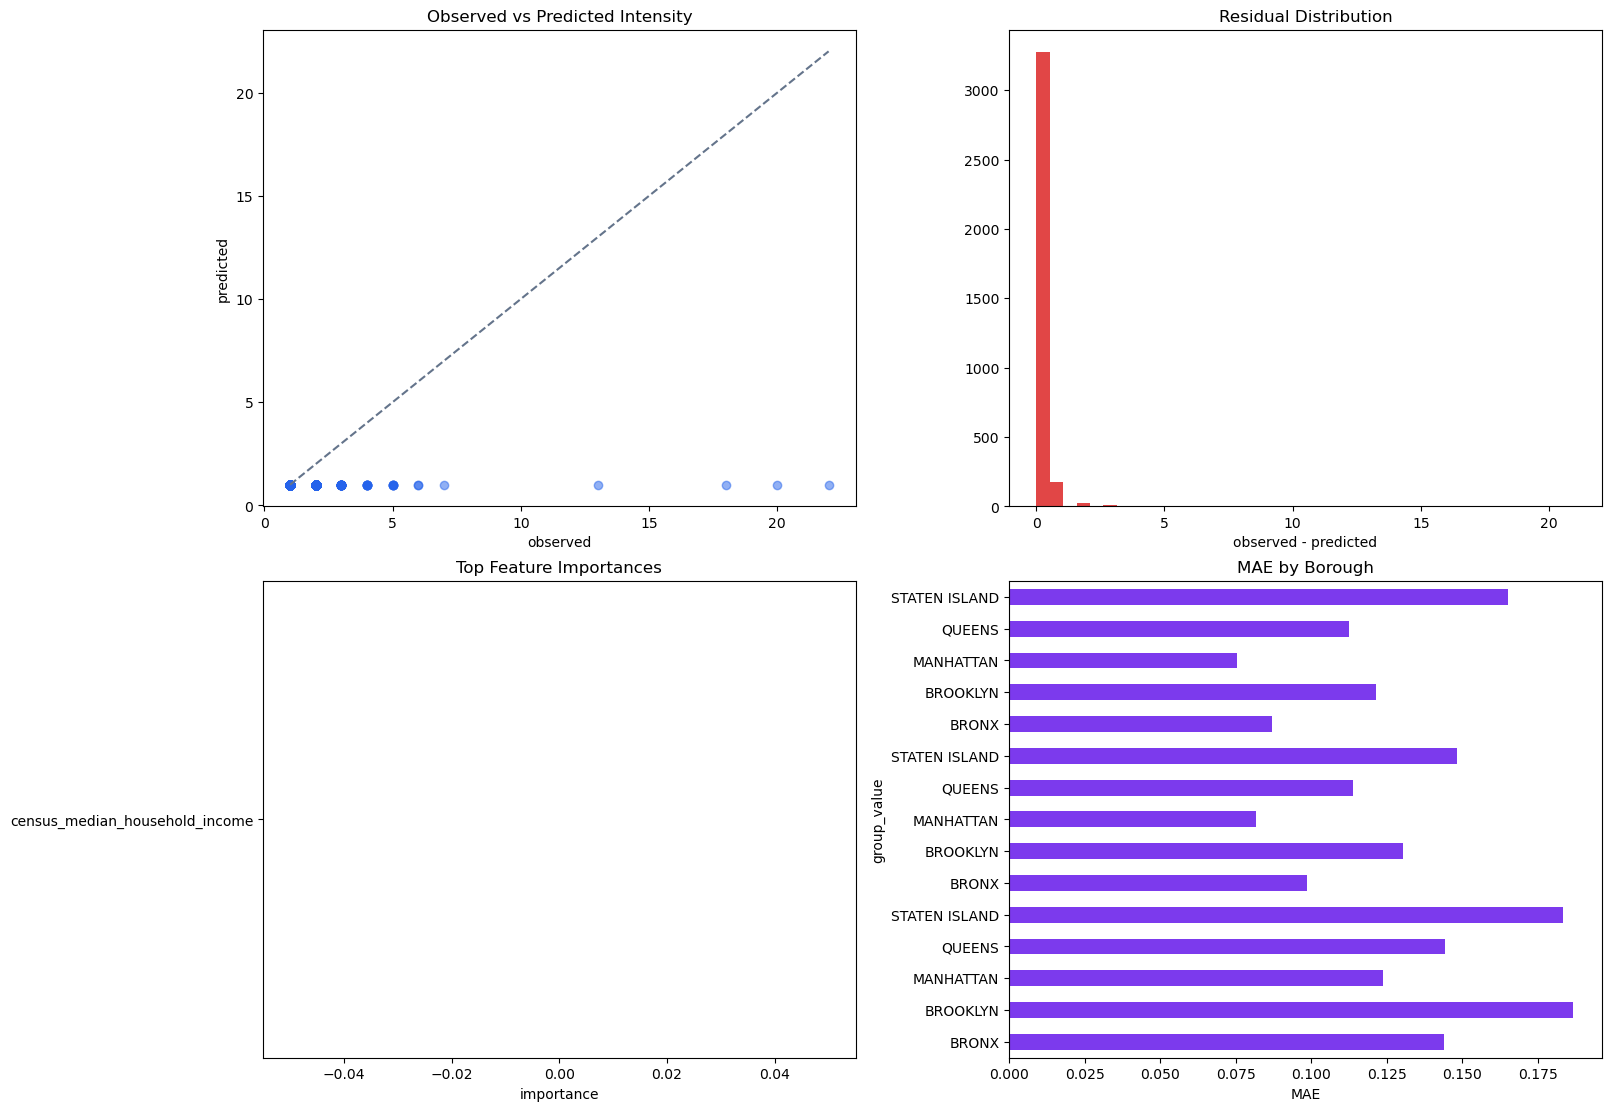

In [7]:
best_row = (
    results.query("status == 'ok'")
    .sort_values(["mae", "rmse"], ascending=[True, True], kind="stable")
    .iloc[0]
)
best_predictions = predictions[
    (predictions["model_name"] == best_row["model_name"])
    & (predictions["split_strategy"] == best_row["split_strategy"])
    & (predictions["set_name"] == "test")
].copy()
best_predictions["residual"] = best_predictions["y_true"] - best_predictions["y_pred"]

fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
axes[0, 0].scatter(best_predictions["y_true"], best_predictions["y_pred"], alpha=0.5, color="#2563EB")
axes[0, 0].plot(
    [best_predictions["y_true"].min(), best_predictions["y_true"].max()],
    [best_predictions["y_true"].min(), best_predictions["y_true"].max()],
    linestyle="--",
    color="#64748B",
)
axes[0, 0].set_title("Observed vs Predicted Intensity")
axes[0, 0].set_xlabel("observed")
axes[0, 0].set_ylabel("predicted")

axes[0, 1].hist(pd.to_numeric(best_predictions["residual"], errors="coerce").dropna(), bins=40, color="#DC2626", alpha=0.85)
axes[0, 1].set_title("Residual Distribution")
axes[0, 1].set_xlabel("observed - predicted")

top_features = feature_importance.head(20).sort_values("importance", kind="stable")
axes[1, 0].barh(top_features["feature"], top_features["importance"], color="#059669")
axes[1, 0].set_title("Top Feature Importances")
axes[1, 0].set_xlabel("importance")

bias.query("bias_dimension == 'borough'").plot.barh(x="group_value", y="mae", ax=axes[1, 1], color="#7C3AED", legend=False)
axes[1, 1].set_title("MAE by Borough")
axes[1, 1].set_xlabel("MAE")
plt.show()